In [2]:
import gymnasium as gym
from bettermdptools.utils.test_env import TestEnv
from bettermdptools.algorithms.rl import RL
from bettermdptools.algorithms.planner import Planner
from bettermdptools.utils.plots import Plots
from bettermdptools.envs.blackjack_wrapper import BlackjackWrapper
from bettermdptools.utils.grid_search import GridSearch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import itertools
import pandas as pd

In [3]:
from bettermdptools.utils.decorators import add_to

@add_to(Plots)
@staticmethod
def modified_plot_policy(val_max, directions, map_size, title):
    """Plot the policy learned."""
    sns.heatmap(
        val_max,
        annot=directions,
        fmt="",
        cmap=sns.color_palette("magma_r", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
    ).set(title=title)
    img_title = f"Policy_{map_size[0]}x{map_size[1]}.png"
    plt.show()
    
def moving_avg(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# 1. BlackJack 
## 1.1 BlackJack Value Iteration

This section applies Value Iteration (VI) to the Blackjack-v1 environment. The code is organized as follows:

1. **Environment Setup**  
   The Blackjack environment is created using `gym.make` and wrapped using `BlackjackWrapper` to enable use with dynamic programming algorithms.

2. **Helper Functions**  
   - `compute_policy_from_V`: Computes Q-values from a given value function and derives the greedy policy.  
   - `run_vi_and_test`: Runs Value Iteration on the environment with specified hyperparameters and returns average reward over 100 test episodes.

3. **Grid Search**  
   A grid search is performed to find the best combination of hyperparameters:
   - `gamma` ∈ [0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]  
   - `n_iters` ∈ [500, 750, 1000, 1250, 1500, 1750, 2000]  
   - `theta` ∈ [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]  
   The configuration that achieves the highest average reward is selected.

4. **Final Training and Evaluation**  
   Using the best parameters found in the grid search, Value Iteration is run again. The resulting policy is evaluated over 100 episodes, and convergence is tracked by recording the mean value of the value function at each iteration.

5. **Visualization**  
   Several plots are generated to illustrate:
   - Sensitivity of average reward to gamma, iteration count, and theta  
   - Convergence curve showing average V values over iterations  
   - Final learned policy heatmap (Stick or Hit) based on state space

running VI with gamma: 0.91  n_iters: 500  theta: 0.01
Avg. episode reward:  -0.1
###################
running VI with gamma: 0.91  n_iters: 500  theta: 0.001
Avg. episode reward:  0.01
###################
running VI with gamma: 0.91  n_iters: 500  theta: 0.0001
Avg. episode reward:  -0.17
###################
running VI with gamma: 0.91  n_iters: 500  theta: 1e-05
Avg. episode reward:  -0.02
###################
running VI with gamma: 0.91  n_iters: 500  theta: 1e-06
Avg. episode reward:  -0.01
###################
running VI with gamma: 0.91  n_iters: 750  theta: 0.01
Avg. episode reward:  -0.18
###################
running VI with gamma: 0.91  n_iters: 750  theta: 0.001
Avg. episode reward:  0.03
###################
running VI with gamma: 0.91  n_iters: 750  theta: 0.0001
Avg. episode reward:  -0.02
###################
running VI with gamma: 0.91  n_iters: 750  theta: 1e-05
Avg. episode reward:  -0.05
###################
running VI with gamma: 0.91  n_iters: 750  theta: 1e-06
Avg. episod

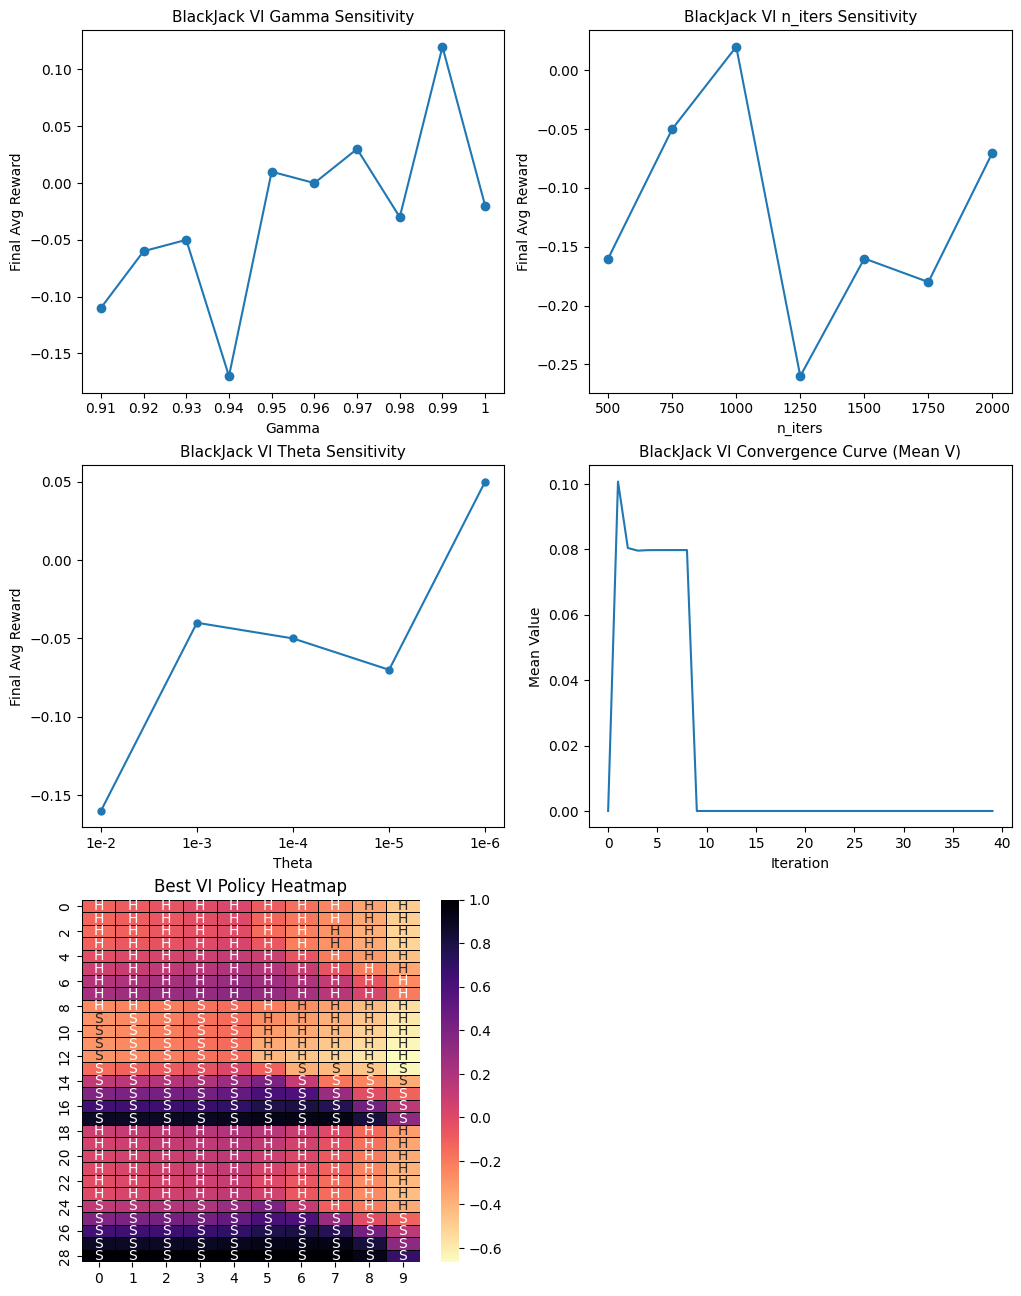

Best Params:
Gamma = 1
n_iters = 1500
Theta = 0.0001
Avg Reward = 0.290


<Figure size 640x480 with 0 Axes>

In [4]:
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)

# -------------------------------
# 1. crate the Blackjack environment
# -------------------------------
base_env = gym.make("Blackjack-v1", render_mode=None)
base_env.reset(seed=seed_value)
blackjack = BlackjackWrapper(base_env)

# helper function: compute the policy from V
def compute_policy_from_V(V, P, gamma):
    num_states = len(V)
    num_actions = len(P[0])
    Q = np.zeros((num_states, num_actions))
    for s in range(num_states):
        for a in range(num_actions):
            for (prob, ns, reward, done) in P[s][a]:
                Q[s, a] += prob * (reward + gamma * V[ns] * (not done))
    policy = {s: int(np.argmax(Q[s])) for s in range(num_states)}
    return policy

# helper function: run value iteration and test the policy
def run_vi_and_test(blackjack_env, gamma, n_iters, theta):
    V, V_track, pi = Planner(blackjack_env.P).value_iteration(
        gamma=gamma, n_iters=n_iters, theta=theta
    )
    episode_rewards = TestEnv.test_env(env=blackjack_env, n_iters=100, pi=pi)
    avg_reward = np.mean(episode_rewards)
    return avg_reward, V_track, pi

# --------------------------------------------
# 2. define hyperparameters for GridSearch
# --------------------------------------------
gamma_candidates = [0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1]
n_iters_candidates = [500, 750, 1000, 1250, 1500, 1750, 2000]
theta_candidates = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

# -----------------------------------------------------
# 3. apply GridSearch to find the best parameters
# -----------------------------------------------------
results, highest_avg_reward, best_params = GridSearch.vi_grid_search(
    blackjack, 
    gamma=gamma_candidates, 
    n_iters=n_iters_candidates, 
    theta=theta_candidates, 
    verbose=True
)

print("\nGrid Search VI Results:")
for r in results:
    print(r)
print("\nBest Avg Reward:", highest_avg_reward)
print("Best Parameters (gamma, n_iters, theta):", best_params)

# -------------------------------------------------
# 4. find the best parameters and run value iteration
# -------------------------------------------------
best_gamma, best_n_iters, best_theta = best_params
V_final, V_track_final, policy_final = Planner(blackjack.P).value_iteration(
    gamma=best_gamma, n_iters=best_n_iters, theta=best_theta
)

# Compute mean(V) per iteration for smoothed convergence plot
mean_V_convergence = np.mean(V_track_final, axis=1)

# --------------------------------------------------------
# 5. test the final policy with TestEnv
# --------------------------------------------------------
episode_rewards = TestEnv.test_env(env=blackjack, n_iters=100, pi=policy_final)
avg_final_reward = np.mean(episode_rewards)

# --------------------------------------------------------------------------------
# 6. plotting: 5 subplots
# --------------------------------------------------------------------------------

baseline_gamma = 0.91
baseline_n_iters = 500
baseline_theta = 1e-2

gamma_results = []
for g in gamma_candidates:
    avg_reward, _, _ = run_vi_and_test(blackjack, gamma=g, n_iters=baseline_n_iters, theta=baseline_theta)
    gamma_results.append(avg_reward)

n_iters_results = []
for ni in n_iters_candidates:
    avg_reward, _, _ = run_vi_and_test(blackjack, gamma=baseline_gamma, n_iters=ni, theta=baseline_theta)
    n_iters_results.append(avg_reward)

theta_results = []
for t in theta_candidates:
    avg_reward, _, _ = run_vi_and_test(blackjack, gamma=baseline_gamma, n_iters=baseline_n_iters, theta=t)
    theta_results.append(avg_reward)

# Heatmap prep
mapping_size = (29, 10)
blackjack_actions = {0: "Stick", 1: "Hit"}
val_map, policy_map = Plots.get_policy_map(policy_final, V_final, blackjack_actions, mapping_size)

fig, axs = plt.subplots(3, 2, figsize=(12, 16))
fig.delaxes(axs[2, 1])

axs[0, 0].plot(list(map(str, gamma_candidates)), gamma_results, marker='o')
axs[0, 0].set_title("BlackJack VI Gamma Sensitivity", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Final Avg Reward")

axs[0, 1].plot(list(map(str, n_iters_candidates)), n_iters_results, marker='o')
axs[0, 1].set_title("BlackJack VI n_iters Sensitivity", fontsize=11)
axs[0, 1].set_xlabel("n_iters")
axs[0, 1].set_ylabel("Final Avg Reward")

axs[1, 0].plot(['1e-2','1e-3','1e-4','1e-5','1e-6'], theta_results, marker='o', markersize=5)
axs[1, 0].set_title("BlackJack VI Theta Sensitivity", fontsize=11)
axs[1, 0].set_xlabel("Theta")
axs[1, 0].set_ylabel("Final Avg Reward")

num = 40
axs[1, 1].plot(range(num),mean_V_convergence[:num])
axs[1, 1].set_title("BlackJack VI Convergence Curve (Mean V)", fontsize=11)
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Mean Value")

plt.sca(axs[2, 0])
Plots.modified_plot_policy(val_map, policy_map, mapping_size, "Best VI Policy Heatmap")
axs[2, 0].set_title("BlackJack Best VI Policy Heatmap")
axs[2, 0].set_xlabel("Dealer Card")
axs[2, 0].set_ylabel("Player State Index")

print(f"Best Params:\nGamma = {best_gamma}\nn_iters = {best_n_iters}\nTheta = {best_theta}\nAvg Reward = {highest_avg_reward:.3f}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 1.2 BlackJack Policy Iteration

This section applies Policy Iteration (PI) to the Blackjack-v1 environment. The code structure includes:

1. **Environment Setup**  
   The environment is created using `gym.make` and wrapped with `BlackjackWrapper`, preparing it for use with tabular reinforcement learning methods.

2. **Helper Functions**  
   - `compute_policy_from_V`: Computes a deterministic policy from a value function.  
   - `run_vi_and_test`: Runs policy iteration with specified parameters and evaluates the resulting policy over 100 episodes.

3. **Grid Search**  
   The code searches for the best hyperparameter combination by evaluating:
   - `gamma` ∈ [0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]  
   - `n_iters` ∈ [500, 750, 1000, 1250, 1500, 1750, 2000]  
   - `theta` ∈ [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]  
   The best parameters are selected based on average reward performance.

4. **Final Training and Evaluation**  
   Policy Iteration is run again with the best parameters, and the final policy is evaluated. Convergence is tracked using the mean value of the value function per iteration.

5. **Visualization**  
   The following plots are generated:
   - Sensitivity of average reward with respect to `gamma`, `n_iters`, and `theta`  
   - Convergence curve showing `mean(V)` over time  
   - A heatmap showing the learned policy's action choice (Stick or Hit) across the state space

running PI with gamma: 0.91  n_iters: 500  theta: 0.01
Avg. episode reward:  -0.1
###################
running PI with gamma: 0.91  n_iters: 500  theta: 0.001
Avg. episode reward:  0.01
###################
running PI with gamma: 0.91  n_iters: 500  theta: 0.0001
Avg. episode reward:  -0.17
###################
running PI with gamma: 0.91  n_iters: 500  theta: 1e-05
Avg. episode reward:  -0.02
###################
running PI with gamma: 0.91  n_iters: 500  theta: 1e-06
Avg. episode reward:  -0.01
###################
running PI with gamma: 0.91  n_iters: 750  theta: 0.01
Avg. episode reward:  -0.18
###################
running PI with gamma: 0.91  n_iters: 750  theta: 0.001
Avg. episode reward:  0.03
###################
running PI with gamma: 0.91  n_iters: 750  theta: 0.0001
Avg. episode reward:  -0.02
###################
running PI with gamma: 0.91  n_iters: 750  theta: 1e-05
Avg. episode reward:  -0.05
###################
running PI with gamma: 0.91  n_iters: 750  theta: 1e-06
Avg. episod

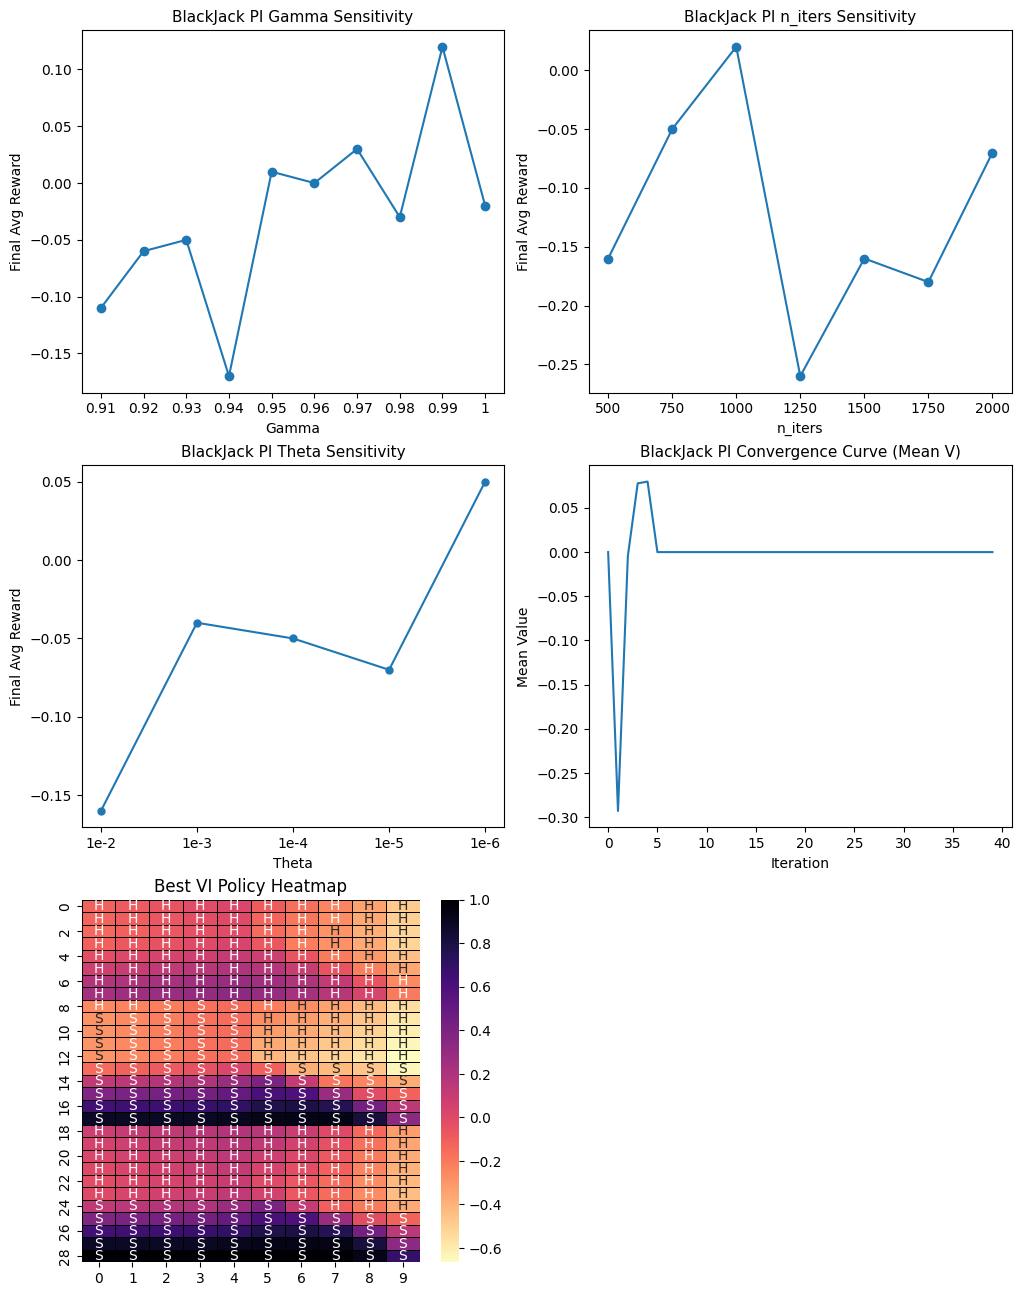

Best Params:
Gamma = 1
n_iters = 1500
Theta = 0.0001
Avg Reward = 0.290


<Figure size 640x480 with 0 Axes>

In [18]:
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)

# -------------------------------
# 1. crate the Blackjack environment
# -------------------------------
base_env = gym.make("Blackjack-v1", render_mode=None)
base_env.reset(seed=seed_value)
blackjack = BlackjackWrapper(base_env)

# helper function: compute the policy from V
def compute_policy_from_V(V, P, gamma):
    num_states = len(V)
    num_actions = len(P[0])
    Q = np.zeros((num_states, num_actions))
    for s in range(num_states):
        for a in range(num_actions):
            for (prob, ns, reward, done) in P[s][a]:
                Q[s, a] += prob * (reward + gamma * V[ns] * (not done))
    policy = {s: int(np.argmax(Q[s])) for s in range(num_states)}
    return policy

# helper function: run value iteration and test the policy
def run_vi_and_test(blackjack_env, gamma, n_iters, theta):
    V, V_track, pi = Planner(blackjack_env.P).policy_iteration(
        gamma=gamma, n_iters=n_iters, theta=theta
    )
    episode_rewards = TestEnv.test_env(env=blackjack_env, n_iters=100, pi=pi)
    avg_reward = np.mean(episode_rewards)
    return avg_reward, V_track, pi

# --------------------------------------------
# 2. define hyperparameters for GridSearch
# --------------------------------------------
gamma_candidates = [0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1]
n_iters_candidates = [500, 750, 1000, 1250, 1500, 1750, 2000]
theta_candidates = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

# -----------------------------------------------------
# 3. apply GridSearch to find the best parameters
# -----------------------------------------------------
results, highest_avg_reward, best_params = GridSearch.pi_grid_search(
    blackjack, 
    gamma=gamma_candidates, 
    n_iters=n_iters_candidates, 
    theta=theta_candidates, 
    verbose=True
)

print("\nGrid Search VI Results:")
for r in results:
    print(r)
print("\nBest Avg Reward:", highest_avg_reward)
print("Best Parameters (gamma, n_iters, theta):", best_params)

# -------------------------------------------------
# 4. find the best parameters and run value iteration
# -------------------------------------------------
best_gamma, best_n_iters, best_theta = best_params
V_final, V_track_final, policy_final = Planner(blackjack.P).policy_iteration(
    gamma=best_gamma, n_iters=best_n_iters, theta=best_theta
)

# Compute mean(V) per iteration for smoothed convergence plot
mean_V_convergence = np.mean(V_track_final, axis=1)

# --------------------------------------------------------
# 5. test the final policy with TestEnv
# --------------------------------------------------------
episode_rewards = TestEnv.test_env(env=blackjack, n_iters=100, pi=policy_final)
avg_final_reward = np.mean(episode_rewards)

# --------------------------------------------------------------------------------
# 6. plotting: 5 subplots
# --------------------------------------------------------------------------------

baseline_gamma = 0.91
baseline_n_iters = 500
baseline_theta = 1e-2

gamma_results = []
for g in gamma_candidates:
    avg_reward, _, _ = run_vi_and_test(blackjack, gamma=g, n_iters=baseline_n_iters, theta=baseline_theta)
    gamma_results.append(avg_reward)

n_iters_results = []
for ni in n_iters_candidates:
    avg_reward, _, _ = run_vi_and_test(blackjack, gamma=baseline_gamma, n_iters=ni, theta=baseline_theta)
    n_iters_results.append(avg_reward)

theta_results = []
for t in theta_candidates:
    avg_reward, _, _ = run_vi_and_test(blackjack, gamma=baseline_gamma, n_iters=baseline_n_iters, theta=t)
    theta_results.append(avg_reward)

# Heatmap prep
mapping_size = (29, 10)
blackjack_actions = {0: "Stick", 1: "Hit"}
val_map, policy_map = Plots.get_policy_map(policy_final, V_final, blackjack_actions, mapping_size)

fig, axs = plt.subplots(3, 2, figsize=(12, 16))
fig.delaxes(axs[2, 1])

axs[0, 0].plot(list(map(str, gamma_candidates)), gamma_results, marker='o')
axs[0, 0].set_title("BlackJack PI Gamma Sensitivity", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Final Avg Reward")

axs[0, 1].plot(list(map(str, n_iters_candidates)), n_iters_results, marker='o')
axs[0, 1].set_title("BlackJack PI n_iters Sensitivity", fontsize=11)
axs[0, 1].set_xlabel("n_iters")
axs[0, 1].set_ylabel("Final Avg Reward")

axs[1, 0].plot(['1e-2','1e-3','1e-4','1e-5','1e-6'], theta_results, marker='o', markersize=5)
axs[1, 0].set_title("BlackJack PI Theta Sensitivity", fontsize=11)
axs[1, 0].set_xlabel("Theta")
axs[1, 0].set_ylabel("Final Avg Reward")

num = 40
axs[1, 1].plot(range(num),mean_V_convergence[:num])
axs[1, 1].set_title("BlackJack PI Convergence Curve (Mean V)", fontsize=11)
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Mean Value")

plt.sca(axs[2, 0])
Plots.modified_plot_policy(val_map, policy_map, mapping_size, "Best VI Policy Heatmap")
axs[2, 0].set_title("BlackJack Best PI Policy Heatmap")
axs[2, 0].set_xlabel("Dealer Card")
axs[2, 0].set_ylabel("Player State Index")

print(f"Best Params:\nGamma = {best_gamma}\nn_iters = {best_n_iters}\nTheta = {best_theta}\nAvg Reward = {highest_avg_reward:.3f}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 1.3 BlackJack SARSA

This section applies SARSA (State-Action-Reward-State-Action) to the Blackjack-v1 environment. The structure of the code is organized as follows:

1. **Environment Setup**  
   The Blackjack environment is initialized and wrapped using `BlackjackWrapper` to prepare it for tabular reinforcement learning.

2. **Helper Functions**  
   - `run_sarsa_and_test`: Trains using the SARSA algorithm with specific hyperparameters, and evaluates the final learned policy over 100 episodes.  
   - `compute_q_convergence`: Computes the mean of Q-values at each iteration to track convergence.  
   - `compute_episode_length_curve`: Measures how the average episode length evolves during training.

3. **Grid Search**  
   A comprehensive hyperparameter search is performed across:
   - `gamma` ∈ [0.91, 0.93, 0.95, 0.97, 0.98, 1.0]  
   - `epsilon_decay` ∈ [0.8, 0.85, 0.9, 0.95, 1.0]  
   - `n_episodes` ∈ [5000, 7500, 10000, 12500, 15000]  
   The best set of parameters is selected based on evaluation performance.

4. **Final Training and Evaluation**  
   SARSA is run again using the best parameters, and metrics like convergence curve, cumulative reward, and episode length are recorded.

5. **Visualization**  
   The following performance visualizations are generated:
   - Reward sensitivity with respect to `gamma`, `epsilon_decay`, and `n_episodes`  
   - Convergence curve using average Q-values  
   - Cumulative reward over training episodes  
   - Episode length curve over time

running sarsa with gamma: 0.91 epsilon decay: 0.8  iterations: 5000


  0%|          | 0/5000 [00:00<?, ?it/s]

Avg. episode reward:  -0.04
###################
running sarsa with gamma: 0.91 epsilon decay: 0.8  iterations: 7500


  0%|          | 0/7500 [00:00<?, ?it/s]

Avg. episode reward:  -0.09
###################
running sarsa with gamma: 0.91 epsilon decay: 0.8  iterations: 10000


...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

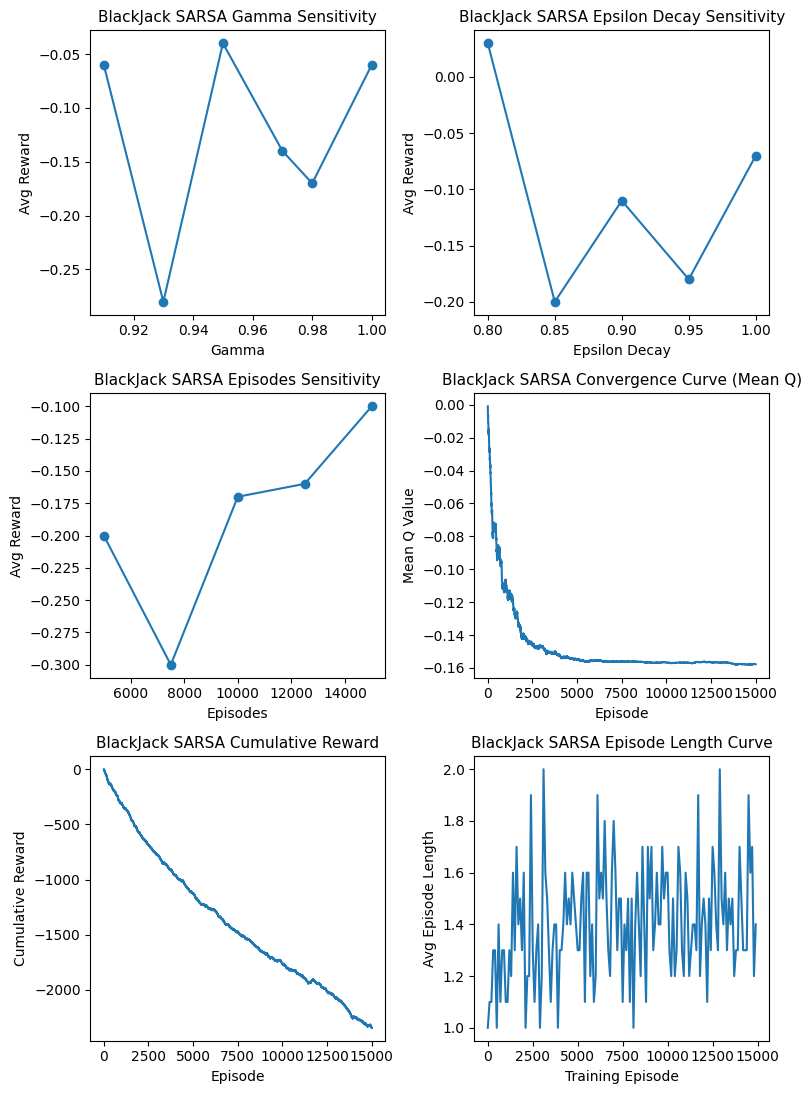

BlackJack Best SARSA Params: Gamma=0.98, Epsilon Decay=0.85, Episodes=15000 | Final Avg Reward=0.27


In [7]:
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)

from bettermdptools.algorithms.rl import RL

# -------------------------------
# 1. Create and wrap the Blackjack environment
# -------------------------------
base_env = gym.make("Blackjack-v1", render_mode=None)
base_env.reset(seed=seed_value)
blackjack = BlackjackWrapper(base_env)

# -------------------------------
# 2. Helper functions
# -------------------------------
def compute_policy_from_V(V, P, gamma):
    num_states = len(V)
    num_actions = len(P[0])
    Q = np.zeros((num_states, num_actions))
    for s in range(num_states):
        for a in range(num_actions):
            for (prob, ns, reward, done) in P[s][a]:
                Q[s, a] += prob * (reward + gamma * V[ns] * (not done))
    policy = {s: int(np.argmax(Q[s])) for s in range(num_states)}
    return policy

def run_sarsa_and_test(blackjack_env, gamma, epsilon_decay, n_episodes):
    Q, V, pi, Q_track, pi_track, rewards = RL(blackjack_env).sarsa(
        nS=290,
        nA=blackjack.env.action_space.n,
        gamma=gamma,
        init_alpha=0.5,
        min_alpha=0.01,
        alpha_decay_ratio=0.5,
        init_epsilon=1.0,
        min_epsilon=0.1,
        epsilon_decay_ratio=epsilon_decay,
        n_episodes=n_episodes
    )
    episode_rewards = TestEnv.test_env(env=blackjack_env, n_iters=100, pi=pi)
    avg_reward = np.mean(episode_rewards)
    return avg_reward, rewards, Q_track, pi, pi_track

def compute_q_convergence(Q_track):
    return np.mean(Q_track, axis=(1, 2))

def compute_episode_length_curve(pi_track, env, sample_interval=100, num_samples=10):
    lengths = []
    for i in range(0, len(pi_track), sample_interval):
        avg_length = []
        for _ in range(num_samples):
            obs, _ = env.reset()
            done = False
            pi = pi_track[i]
            step_count = 0
            while not done:
                action = pi[obs]
                obs, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                step_count += 1
            avg_length.append(step_count)
        lengths.append(np.mean(avg_length))
    return lengths

# -------------------------------
# 3. Define hyperparameter candidates
# -------------------------------
gamma_candidates = [0.91, 0.93, 0.95, 0.97, 0.98, 1]
epsilon_decay_candidates = [0.8, 0.85, 0.9, 0.95, 1.0]
episodes_candidates = [5000, 7500, 10000, 12500, 15000]

# -------------------------------
# 4. Grid Search for SARSA
# -------------------------------
sarsa_results, grid_best_avg_reward, grid_best_params = GridSearch.sarsa_grid_search(
    blackjack,
    gamma=gamma_candidates,
    epsilon_decay=epsilon_decay_candidates,
    iters=episodes_candidates,
    verbose=True
)

print("\nSARSA Grid Search Results:")
for r in sarsa_results:
    print(r)
print("\nBest SARSA Avg Reward from Grid Search:", grid_best_avg_reward)
print("Best SARSA Params (gamma, epsilon_decay, n_episodes):", grid_best_params)

# -------------------------------
# 5. Final SARSA Training
# -------------------------------
best_gamma, best_epsilon_decay, best_episodes = grid_best_params
final_avg_reward, rewards_history, Q_track_final, final_policy, policy_track = run_sarsa_and_test(
    blackjack, best_gamma, best_epsilon_decay, best_episodes
)
print("\nFinal SARSA instance average reward:", final_avg_reward)
print("\nFinal SARSA Policy (state: action):")
print(final_policy)

BlackJack_Sarsa_reward_record = rewards_history

# -------------------------------
# 6. Compute metrics for plots
# -------------------------------
convergence_values = compute_q_convergence(Q_track_final)
cumulative_rewards = np.cumsum(rewards_history)
episode_lengths = compute_episode_length_curve(policy_track, blackjack, sample_interval=100, num_samples=10)
iterations_sampled = list(range(0, len(policy_track), 100))

# -------------------------------
# 7. Sensitivity curves
# -------------------------------
baseline_gamma = 0.91
baseline_epsilon_decay = 0.8
baseline_episodes = 5000

gamma_sensitivity = [run_sarsa_and_test(blackjack, gamma=g, epsilon_decay=baseline_epsilon_decay, n_episodes=baseline_episodes)[0] for g in gamma_candidates]
epsilon_decay_sensitivity = [run_sarsa_and_test(blackjack, gamma=baseline_gamma, epsilon_decay=ed, n_episodes=baseline_episodes)[0] for ed in epsilon_decay_candidates]
episodes_sensitivity = [run_sarsa_and_test(blackjack, gamma=baseline_gamma, epsilon_decay=baseline_epsilon_decay, n_episodes=ep)[0] for ep in episodes_candidates]

# -------------------------------
# 8. Plotting 6 subplots
# -------------------------------
fig, axs = plt.subplots(3, 2, figsize=(8, 12))

axs[0, 0].plot(gamma_candidates, gamma_sensitivity, marker='o')
axs[0, 0].set_title("BlackJack SARSA Gamma Sensitivity", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Avg Reward")

axs[0, 1].plot(epsilon_decay_candidates, epsilon_decay_sensitivity, marker='o')
axs[0, 1].set_title("BlackJack SARSA Epsilon Decay Sensitivity", fontsize=11)
axs[0, 1].set_xlabel("Epsilon Decay")
axs[0, 1].set_ylabel("Avg Reward")

axs[1, 0].plot(episodes_candidates, episodes_sensitivity, marker='o')
axs[1, 0].set_title("BlackJack SARSA Episodes Sensitivity", fontsize=11)
axs[1, 0].set_xlabel("Episodes")
axs[1, 0].set_ylabel("Avg Reward")

axs[1, 1].plot(convergence_values)
axs[1, 1].set_title("BlackJack SARSA Convergence Curve (Mean Q)", fontsize=11)
axs[1, 1].set_xlabel("Episode")
axs[1, 1].set_ylabel("Mean Q Value")

axs[2, 0].plot(cumulative_rewards)
axs[2, 0].set_title("BlackJack SARSA Cumulative Reward", fontsize=11)
axs[2, 0].set_xlabel("Episode")
axs[2, 0].set_ylabel("Cumulative Reward")

axs[2, 1].plot(iterations_sampled, episode_lengths)
axs[2, 1].set_title("BlackJack SARSA Episode Length Curve", fontsize=11)
axs[2, 1].set_xlabel("Training Episode")
axs[2, 1].set_ylabel("Avg Episode Length")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print(f"BlackJack Best SARSA Params: Gamma={best_gamma}, Epsilon Decay={best_epsilon_decay}, Episodes={best_episodes} | Final Avg Reward={grid_best_avg_reward:.2f}")


## 1.4 BlackJack Q Learning

This section applies the Q-Learning algorithm to the Blackjack-v1 environment. The structure is organized as follows:

1. **Environment Setup**  
   The Blackjack environment is created and wrapped with `BlackjackWrapper` to prepare a tabular state space for reinforcement learning.

2. **Helper Functions**  
   - `run_qlearning_and_test`: Executes Q-Learning training under given hyperparameters and evaluates the resulting policy.  
   - `compute_q_convergence`: Computes the mean Q-value at each training step for convergence tracking.  
   - `compute_episode_length_curve`: Tracks average episode length over time for stability analysis.

3. **Grid Search**  
   A search is conducted over the following hyperparameter ranges:  
   - `gamma`: [0.91, 0.93, 0.95, 0.97, 0.98, 1.0]  
   - `epsilon_decay`: [0.8, 0.85, 0.9, 0.95, 1.0]  
   - `n_episodes`: [5000, 7500, 10000, 12500, 15000]  
   The combination that produces the highest average reward is selected.

4. **Final Training and Evaluation**  
   Q-Learning is re-run using the best parameter set, and performance metrics such as convergence, cumulative rewards, and episode lengths are recorded.

5. **Visualization**  
   Six subplots are generated to visualize:  
   - Sensitivity to `gamma`, `epsilon_decay`, and `n_episodes`  
   - Convergence curve based on mean Q-values  
   - Accumulated reward over episodes  
   - Average episode length during training

running q_learning with gamma: 0.91 epsilon decay: 0.8  iterations: 5000


  0%|          | 0/5000 [00:00<?, ?it/s]

Avg. episode reward:  -0.2
###################
running q_learning with gamma: 0.91 epsilon decay: 0.8  iterations: 7500


  0%|          | 0/7500 [00:00<?, ?it/s]

Avg. episode reward:  -0.08
###################
running q_learning with gamma: 0.91 epsilon decay: 0.8  iterations: 10000


...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

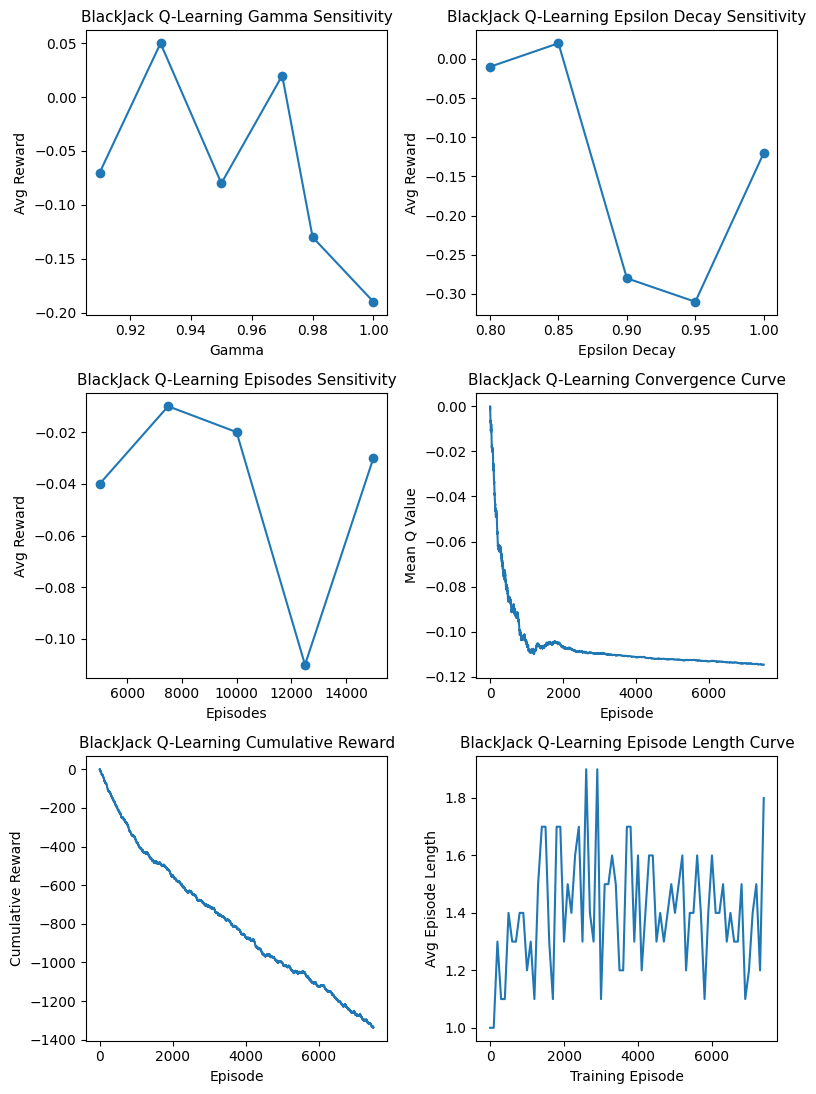

BlackJack Best Q-Learning Params: Gamma=0.98, Epsilon Decay=0.8, Episodes=7500 | Final Avg Reward=0.19


In [8]:
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)

from bettermdptools.algorithms.rl import RL

# -------------------------------
# 1. Create and wrap the Blackjack environment
# -------------------------------
base_env = gym.make("Blackjack-v1", render_mode=None)
base_env.reset(seed=seed_value)
blackjack = BlackjackWrapper(base_env)

# -------------------------------
# 2. Helper functions
# -------------------------------
def compute_policy_from_V(V, P, gamma):
    num_states = len(V)
    num_actions = len(P[0])
    Q = np.zeros((num_states, num_actions))
    for s in range(num_states):
        for a in range(num_actions):
            for (prob, ns, reward, done) in P[s][a]:
                Q[s, a] += prob * (reward + gamma * V[ns] * (not done))
    policy = {s: int(np.argmax(Q[s])) for s in range(num_states)}
    return policy

def run_qlearning_and_test(blackjack_env, gamma, epsilon_decay, n_episodes):
    Q, V, pi, Q_track, pi_track, rewards = RL(blackjack_env).q_learning(
        nS=290,
        nA=blackjack.env.action_space.n,
        gamma=gamma,
        init_alpha=0.5,
        min_alpha=0.01,
        alpha_decay_ratio=0.5,
        init_epsilon=1.0,
        min_epsilon=0.1,
        epsilon_decay_ratio=epsilon_decay,
        n_episodes=n_episodes
    )
    episode_rewards = TestEnv.test_env(env=blackjack_env, n_iters=100, pi=pi)
    avg_reward = np.mean(episode_rewards)
    return avg_reward, rewards, Q_track, pi, pi_track

def compute_q_convergence(Q_track):
    return np.mean(Q_track, axis=(1, 2))

def compute_episode_length_curve(pi_track, env, sample_interval=100, num_samples=10):
    lengths = []
    for i in range(0, len(pi_track), sample_interval):
        avg_length = []
        for _ in range(num_samples):
            obs, _ = env.reset()
            done = False
            pi = pi_track[i]
            step_count = 0
            while not done:
                action = pi[obs]
                obs, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                step_count += 1
            avg_length.append(step_count)
        lengths.append(np.mean(avg_length))
    return lengths

# -------------------------------
# 3. Hyperparameter candidates
# -------------------------------
gamma_candidates = [0.91, 0.93, 0.95, 0.97, 0.98, 1.0]
epsilon_decay_candidates = [0.8, 0.85, 0.9, 0.95, 1.0]
episodes_candidates = [5000, 7500, 10000, 12500, 15000]

# -------------------------------
# 4. Grid Search for Q-learning
# -------------------------------
q_results, grid_best_avg_reward, grid_best_params = GridSearch.q_learning_grid_search(
    blackjack,
    gamma=gamma_candidates,
    epsilon_decay=epsilon_decay_candidates,
    iters=episodes_candidates,
    verbose=True
)

print("\nQ-Learning Grid Search Results:")
for r in q_results:
    print(r)
print("\nBest Q-Learning Avg Reward:", grid_best_avg_reward)
print("Best Q-Learning Params (gamma, epsilon_decay, n_episodes):", grid_best_params)

# -------------------------------
# 5. Final Q-learning Training
# -------------------------------
best_gamma, best_epsilon_decay, best_episodes = grid_best_params
final_avg_reward, rewards_history, Q_track_final, final_policy, policy_track = run_qlearning_and_test(
    blackjack, best_gamma, best_epsilon_decay, best_episodes
)

BlackJack_Qlearning_reward_record = rewards_history

# -------------------------------
# 6. Metrics for plots
# -------------------------------
convergence_values = compute_q_convergence(Q_track_final)
cumulative_rewards = np.cumsum(rewards_history)
episode_lengths = compute_episode_length_curve(policy_track, blackjack, sample_interval=100, num_samples=10)
iterations_sampled = list(range(0, len(policy_track), 100))

# -------------------------------
# 7. Sensitivity curves
# -------------------------------
baseline_gamma = 0.91
baseline_epsilon_decay = 0.8
baseline_episodes = 5000

gamma_sensitivity = [run_qlearning_and_test(blackjack, gamma=g, epsilon_decay=baseline_epsilon_decay, n_episodes=baseline_episodes)[0] for g in gamma_candidates]
epsilon_decay_sensitivity = [run_qlearning_and_test(blackjack, gamma=baseline_gamma, epsilon_decay=ed, n_episodes=baseline_episodes)[0] for ed in epsilon_decay_candidates]
episodes_sensitivity = [run_qlearning_and_test(blackjack, gamma=baseline_gamma, epsilon_decay=baseline_epsilon_decay, n_episodes=ep)[0] for ep in episodes_candidates]

# -------------------------------
# 8. Plotting
# -------------------------------
fig, axs = plt.subplots(3, 2, figsize=(8, 12))

axs[0, 0].plot(gamma_candidates, gamma_sensitivity, marker='o')
axs[0, 0].set_title("BlackJack Q-Learning Gamma Sensitivity", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Avg Reward")

axs[0, 1].plot(epsilon_decay_candidates, epsilon_decay_sensitivity, marker='o')
axs[0, 1].set_title("BlackJack Q-Learning Epsilon Decay Sensitivity", fontsize=11)
axs[0, 1].set_xlabel("Epsilon Decay")
axs[0, 1].set_ylabel("Avg Reward")

axs[1, 0].plot(episodes_candidates, episodes_sensitivity, marker='o')
axs[1, 0].set_title("BlackJack Q-Learning Episodes Sensitivity", fontsize=11)
axs[1, 0].set_xlabel("Episodes")
axs[1, 0].set_ylabel("Avg Reward")

axs[1, 1].plot(convergence_values)
axs[1, 1].set_title("BlackJack Q-Learning Convergence Curve", fontsize=11)
axs[1, 1].set_xlabel("Episode")
axs[1, 1].set_ylabel("Mean Q Value")

axs[2, 0].plot(cumulative_rewards)
axs[2, 0].set_title("BlackJack Q-Learning Cumulative Reward", fontsize=11)
axs[2, 0].set_xlabel("Episode")
axs[2, 0].set_ylabel("Cumulative Reward")

axs[2, 1].plot(iterations_sampled, episode_lengths)
axs[2, 1].set_title("BlackJack Q-Learning Episode Length Curve", fontsize=11)
axs[2, 1].set_xlabel("Training Episode")
axs[2, 1].set_ylabel("Avg Episode Length")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print(f"BlackJack Best Q-Learning Params: Gamma={best_gamma}, Epsilon Decay={best_epsilon_decay}, Episodes={best_episodes} | Final Avg Reward={grid_best_avg_reward:.2f}")



# 2. CartPole
## 2.1 CartPole Value Iteration

This section applies the Value Iteration algorithm to the CartPole-v1 environment. The code is structured as follows:

1. **Environment Setup**  
   The CartPole environment is created and wrapped using `CartpoleWrapper` to discretize continuous state variables into a finite MDP for planning.

2. **Helper Functions**  
   - `run_vi_and_test`: Runs Value Iteration given specific hyperparameters and evaluates the resulting policy.  
   - `compute_policy_from_V`: Converts the learned value function into a deterministic policy.  

3. **Grid Search for Hyperparameter Tuning**  
   A grid search is performed over the following parameter ranges:  
   - `gamma`: [0.91, 0.93, 0.95, 0.97]  
   - `n_iters`: [30, 50, 100, 150]  
   - `theta`: [1e-2, 1e-3, 1e-4, 1e-5]  
   The configuration achieving the highest average reward over 100 evaluation episodes is selected.

4. **Final Training and Evaluation**  
   Value Iteration is rerun using the best hyperparameters. The policy is tested to compute the final average reward and a convergence curve is generated by tracking mean V values.

5. **Visualization**  
   Five plots are produced to show:  
   - Sensitivity to `gamma`, `n_iters`, and `theta`  
   - Convergence curve of the value function  
   - Impact of discretization granularity (`bins`) on average reward performance

In [9]:
from bettermdptools.envs.cartpole_wrapper import CartpoleWrapper

running VI with gamma: 0.91  n_iters: 30  theta: 0.01


C:\Users\louis\AppData\Roaming\Python\Python312\site-packages\bettermdptools\algorithms\planner.py:82: UserWarning: Max iterations reached before convergence.  Check n_iters.
  warnings.warn("Max iterations reached before convergence.  Check n_iters.")


Avg. episode reward:  9.46
###################
running VI with gamma: 0.91  n_iters: 30  theta: 0.001
Avg. episode reward:  9.48
###################
running VI with gamma: 0.91  n_iters: 30  theta: 0.0001
Avg. episode reward:  9.26
###################
running VI with gamma: 0.91  n_iters: 30  theta: 1e-05
Avg. episode reward:  9.29
###################
running VI with gamma: 0.91  n_iters: 50  theta: 0.01
Avg. episode reward:  9.27
###################
running VI with gamma: 0.91  n_iters: 50  theta: 0.001
Avg. episode reward:  9.37
###################
running VI with gamma: 0.91  n_iters: 50  theta: 0.0001
Avg. episode reward:  9.33
###################
running VI with gamma: 0.91  n_iters: 50  theta: 1e-05
Avg. episode reward:  9.44
###################
running VI with gamma: 0.91  n_iters: 100  theta: 0.01
Avg. episode reward:  9.4
###################
running VI with gamma: 0.91  n_iters: 100  theta: 0.001
Avg. episode reward:  9.27
###################
running VI with gamma: 0.91  n_ite

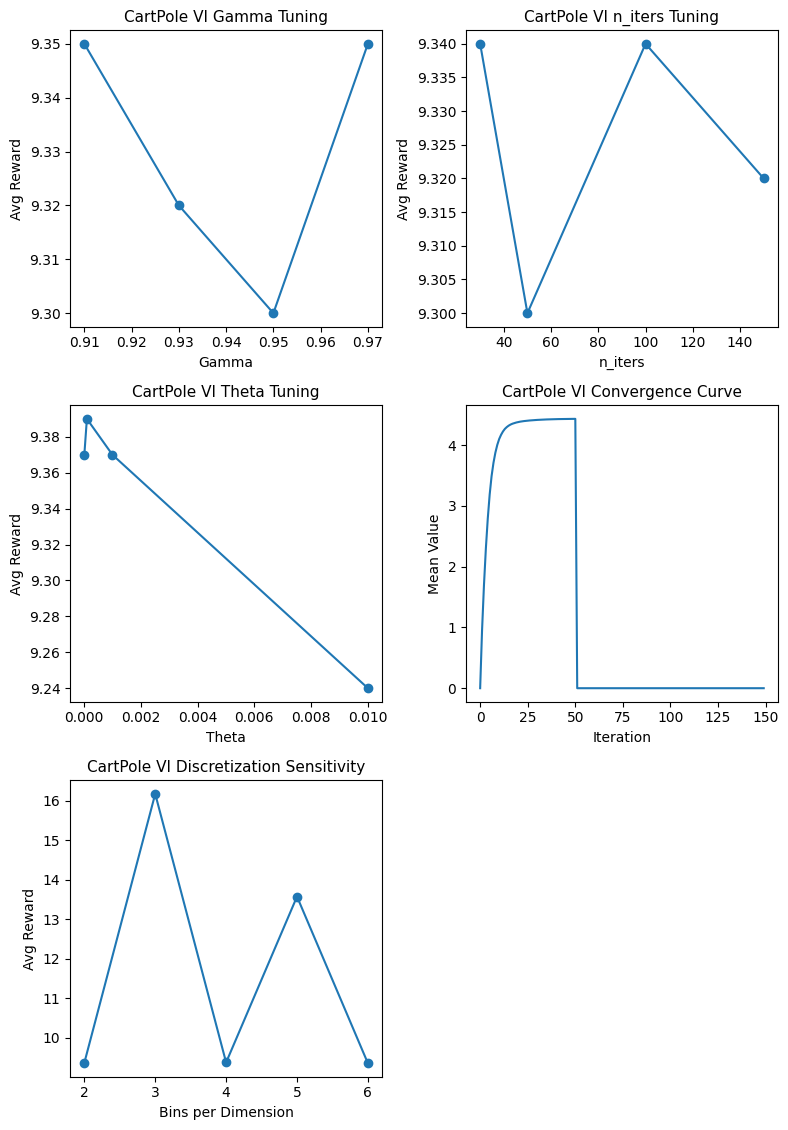

Best VI Params: V=0.91, n_iters=150, θ=0.01 | Avg Reward = 9.34


In [10]:
# -------------------------------
# 1. Create and wrap the CartPole environment
# -------------------------------
base_env = gym.make("CartPole-v1", render_mode=None)
base_env.reset(seed=seed_value)
cartpole = CartpoleWrapper(base_env)

# -------------------------------
# 2. Helper functions
# -------------------------------
def compute_policy_from_V(V, P, gamma):
    num_states = len(V)
    num_actions = len(P[0])
    Q = np.zeros((num_states, num_actions))
    for s in range(num_states):
        for a in range(num_actions):
            for (prob, ns, reward, done) in P[s][a]:
                Q[s, a] += prob * (reward + gamma * V[ns] * (not done))
    policy = {s: int(np.argmax(Q[s])) for s in range(num_states)}
    return policy

def run_vi_and_test(env, gamma, n_iters, theta):
    V, V_track, pi = Planner(env.P).value_iteration(gamma=gamma, n_iters=n_iters, theta=theta)
    episode_rewards = TestEnv.test_env(env=env, n_iters=100, pi=pi)
    avg_reward = np.mean(episode_rewards)
    return avg_reward, V_track, pi

# -------------------------------
# 3. Hyperparameter settings
# -------------------------------
gamma_candidates = [0.91, 0.93, 0.95, 0.97]
n_iters_candidates = [30, 50, 100, 150]
theta_candidates = [1e-2, 1e-3, 1e-4, 1e-5]

# -------------------------------
# 4. Grid Search over hyperparameters
# -------------------------------
results, highest_avg_reward, best_params = GridSearch.vi_grid_search(
    cartpole,
    gamma=gamma_candidates,
    n_iters=n_iters_candidates,
    theta=theta_candidates,
    verbose=True
)

print("\nGrid Search VI Results:")
for r in results:
    print(r)
print("\nBest Avg Reward:", highest_avg_reward)
print("Best Parameters (gamma, n_iters, theta):", best_params)

# -------------------------------
# 5. Final Value Iteration using best params
# -------------------------------
best_gamma, best_n_iters, best_theta = best_params
V_final, V_track_final, policy_final = Planner(cartpole.P).value_iteration(
    gamma=best_gamma, n_iters=best_n_iters, theta=best_theta
)
episode_rewards = TestEnv.test_env(env=cartpole, n_iters=100, pi=policy_final)
avg_final_reward = np.mean(episode_rewards)
print("\nFinal average reward:", avg_final_reward)

# -------------------------------
# 6. Sensitivity plots and convergence
# -------------------------------
gamma_results = [run_vi_and_test(cartpole, gamma=g, n_iters=50, theta=1e-2)[0] for g in gamma_candidates]
n_iters_results = [run_vi_and_test(cartpole, gamma=0.91, n_iters=ni, theta=1e-2)[0] for ni in n_iters_candidates]
theta_results = [run_vi_and_test(cartpole, gamma=0.91, n_iters=50, theta=t)[0] for t in theta_candidates]
mean_V_convergence = np.mean(V_track_final, axis=1)

# -------------------------------
# 7. Discretization Sensitivity Analysis (updated)
# -------------------------------
bin_settings = [2, 3, 4, 5, 6]
avg_rewards_bins = []
for b in bin_settings:
    env = gym.make("CartPole-v1")
    wrapper = CartpoleWrapper(
        env,
        position_bins=b,
        velocity_bins=b,
        angular_velocity_bins=b
    )
    V, _, pi = Planner(wrapper.P).value_iteration(
        gamma=best_gamma,
        n_iters=best_n_iters,
        theta=best_theta)
    avg_reward = np.mean(TestEnv.test_env(env=wrapper, n_iters=100, pi=pi))
    avg_rewards_bins.append(avg_reward)

# -------------------------------
# 8. Plotting all 5 figures
# -------------------------------
fig, axs = plt.subplots(3, 2, figsize=(8, 12))
fig.delaxes(axs[2, 1])  # remove unused subplot

axs[0, 0].plot(gamma_candidates, gamma_results, marker='o')
axs[0, 0].set_title("CartPole VI Gamma Tuning", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Avg Reward")

axs[0, 1].plot(n_iters_candidates, n_iters_results, marker='o')
axs[0, 1].set_title("CartPole VI n_iters Tuning", fontsize=11)
axs[0, 1].set_xlabel("n_iters")
axs[0, 1].set_ylabel("Avg Reward")

axs[1, 0].plot(theta_candidates, theta_results, marker='o')
axs[1, 0].set_title("CartPole VI Theta Tuning", fontsize=11)
axs[1, 0].set_xlabel("Theta")
axs[1, 0].set_ylabel("Avg Reward")

axs[1, 1].plot(mean_V_convergence)
axs[1, 1].set_title("CartPole VI Convergence Curve", fontsize=11)
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Mean Value")

axs[2, 0].plot(bin_settings, avg_rewards_bins, marker='o')
axs[2, 0].set_title("CartPole VI Discretization Sensitivity", fontsize=11)
axs[2, 0].set_xlabel("Bins per Dimension")
axs[2, 0].set_ylabel("Avg Reward")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"Best VI Params: V={best_gamma}, n_iters={best_n_iters}, θ={best_theta} | Avg Reward = {avg_final_reward:.2f}")


## 2.2 Cartpole Policy Iteration

This section applies the Policy Iteration (PI) algorithm to the CartPole-v1 environment. The environment is first wrapped into a discrete MDP using `CartpoleWrapper` for compatibility with planning algorithms.

**Code structure summary:**

1. **Environment Setup**  
   Initializes the CartPole environment and discretizes continuous state variables.

2. **Helper Functions**  
   - `run_pi_and_test`: Executes policy iteration and evaluates the resulting policy.  
   - `compute_policy_from_V`: Converts a value function into a greedy deterministic policy.

3. **Hyperparameter Grid Search**  
   Searches for the best configuration over the following ranges:  
   - `gamma`: [0.91, 0.93, 0.95, 0.97]  
   - `n_iters`: [30, 50, 100, 150]  
   - `theta`: [1e-2, 1e-3, 1e-4, 1e-5]  
   The best setting is selected based on evaluation over 100 test episodes.

4. **Final Training & Evaluation**  
   Trains with the best parameters and plots the convergence of the value function (`mean(V)` per iteration).

5. **Visualization**  
   - Sensitivity plots for `gamma`, `n_iters`, and `theta`  
   - Value convergence curve  
   - Reward performance under different discretization granularities (`bins`)

running PI with gamma: 0.91  n_iters: 30  theta: 0.01
Avg. episode reward:  9.46
###################
running PI with gamma: 0.91  n_iters: 30  theta: 0.001
Avg. episode reward:  9.48
###################
running PI with gamma: 0.91  n_iters: 30  theta: 0.0001
Avg. episode reward:  9.26
###################
running PI with gamma: 0.91  n_iters: 30  theta: 1e-05
Avg. episode reward:  9.29
###################
running PI with gamma: 0.91  n_iters: 50  theta: 0.01
Avg. episode reward:  9.27
###################
running PI with gamma: 0.91  n_iters: 50  theta: 0.001
Avg. episode reward:  9.37
###################
running PI with gamma: 0.91  n_iters: 50  theta: 0.0001
Avg. episode reward:  9.33
###################
running PI with gamma: 0.91  n_iters: 50  theta: 1e-05
Avg. episode reward:  9.44
###################
running PI with gamma: 0.91  n_iters: 100  theta: 0.01
Avg. episode reward:  9.4
###################
running PI with gamma: 0.91  n_iters: 100  theta: 0.001
Avg. episode reward:  9.27


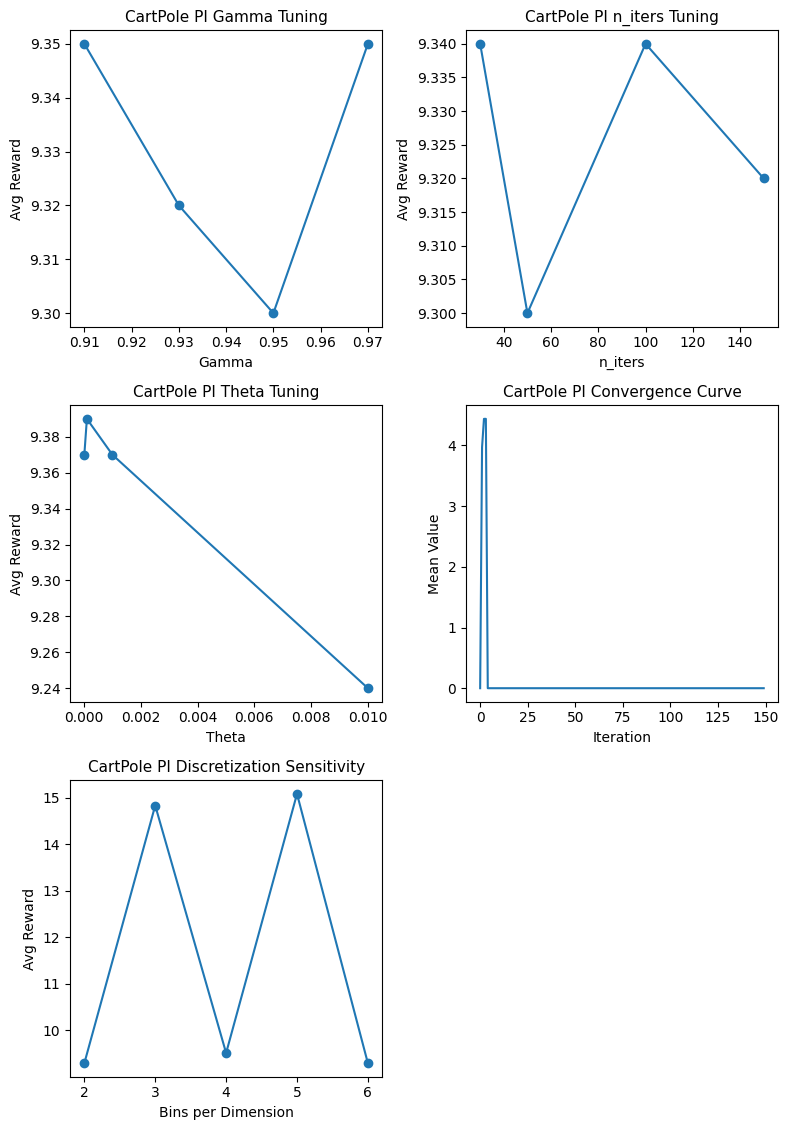

Best PI Params: V=0.91, n_iters=150, θ=0.01 | Avg Reward = 9.34


In [13]:
# -------------------------------
# 1. Create and wrap the CartPole environment
# -------------------------------
base_env = gym.make("CartPole-v1", render_mode=None)
base_env.reset(seed=seed_value)
cartpole = CartpoleWrapper(base_env)

# -------------------------------
# 2. Helper functions
# -------------------------------
def compute_policy_from_V(V, P, gamma):
    num_states = len(V)
    num_actions = len(P[0])
    Q = np.zeros((num_states, num_actions))
    for s in range(num_states):
        for a in range(num_actions):
            for (prob, ns, reward, done) in P[s][a]:
                Q[s, a] += prob * (reward + gamma * V[ns] * (not done))
    policy = {s: int(np.argmax(Q[s])) for s in range(num_states)}
    return policy

def run_pi_and_test(env, gamma, n_iters, theta):
    V, V_track, pi = Planner(env.P).policy_iteration(gamma=gamma, n_iters=n_iters, theta=theta)
    episode_rewards = TestEnv.test_env(env=env, n_iters=100, pi=pi)
    avg_reward = np.mean(episode_rewards)
    return avg_reward, V_track, pi

# -------------------------------
# 3. Hyperparameter settings
# -------------------------------
gamma_candidates = [0.91, 0.93, 0.95, 0.97]
n_iters_candidates = [30, 50, 100, 150]
theta_candidates = [1e-2, 1e-3, 1e-4, 1e-5]

# -------------------------------
# 4. Grid Search over hyperparameters
# -------------------------------
results, highest_avg_reward, best_params = GridSearch.pi_grid_search(
    cartpole,
    gamma=gamma_candidates,
    n_iters=n_iters_candidates,
    theta=theta_candidates,
    verbose=True
)

print("\nGrid Search PI Results:")
for r in results:
    print(r)
print("\nBest Avg Reward:", highest_avg_reward)
print("Best Parameters (gamma, n_iters, theta):", best_params)

# -------------------------------
# 5. Final Policy Iteration using best params
# -------------------------------
best_gamma, best_n_iters, best_theta = best_params
V_final, V_track_final, policy_final = Planner(cartpole.P).policy_iteration(
    gamma=best_gamma, n_iters=best_n_iters, theta=best_theta
)
episode_rewards = TestEnv.test_env(env=cartpole, n_iters=100, pi=policy_final)
avg_final_reward = np.mean(episode_rewards)
print("\nFinal average reward:", avg_final_reward)

# -------------------------------
# 6. Sensitivity plots and convergence
# -------------------------------
gamma_results = [run_pi_and_test(cartpole, gamma=g, n_iters=50, theta=1e-2)[0] for g in gamma_candidates]
n_iters_results = [run_pi_and_test(cartpole, gamma=0.91, n_iters=ni, theta=1e-2)[0] for ni in n_iters_candidates]
theta_results = [run_pi_and_test(cartpole, gamma=0.91, n_iters=50, theta=t)[0] for t in theta_candidates]
mean_V_convergence = np.mean(V_track_final, axis=1)

# -------------------------------
# 7. Discretization Sensitivity Analysis (updated)
# -------------------------------
bin_settings = [2, 3, 4, 5, 6]
avg_rewards_bins = []
for b in bin_settings:
    env = gym.make("CartPole-v1")
    wrapper = CartpoleWrapper(
        env,
        position_bins=b,
        velocity_bins=b,
        angular_velocity_bins=b
    )
    V, _, pi = Planner(wrapper.P).policy_iteration(
        gamma=best_gamma,
        n_iters=best_n_iters,
        theta=best_theta)
    avg_reward = np.mean(TestEnv.test_env(env=wrapper, n_iters=100, pi=pi))
    avg_rewards_bins.append(avg_reward)

# -------------------------------
# 8. Plotting all 5 figures
# -------------------------------
fig, axs = plt.subplots(3, 2, figsize=(8, 12))
fig.delaxes(axs[2, 1])  # remove unused subplot

axs[0, 0].plot(gamma_candidates, gamma_results, marker='o')
axs[0, 0].set_title("CartPole PI Gamma Tuning", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Avg Reward")

axs[0, 1].plot(n_iters_candidates, n_iters_results, marker='o')
axs[0, 1].set_title("CartPole PI n_iters Tuning", fontsize=11)
axs[0, 1].set_xlabel("n_iters")
axs[0, 1].set_ylabel("Avg Reward")

axs[1, 0].plot(theta_candidates, theta_results, marker='o')
axs[1, 0].set_title("CartPole PI Theta Tuning", fontsize=11)
axs[1, 0].set_xlabel("Theta")
axs[1, 0].set_ylabel("Avg Reward")

axs[1, 1].plot(mean_V_convergence)
axs[1, 1].set_title("CartPole PI Convergence Curve", fontsize=11)
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Mean Value")

axs[2, 0].plot(bin_settings, avg_rewards_bins, marker='o')
axs[2, 0].set_title("CartPole PI Discretization Sensitivity", fontsize=11)
axs[2, 0].set_xlabel("Bins per Dimension")
axs[2, 0].set_ylabel("Avg Reward")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"Best PI Params: V={best_gamma}, n_iters={best_n_iters}, θ={best_theta} | Avg Reward = {avg_final_reward:.2f}")


## 2.3 Cartpole Sarsa

This section applies the SARSA algorithm to the CartPole-v1 environment, after discretizing the continuous state space using `CartpoleWrapper`.

**Code structure summary:**

1. **Environment Setup**  
   Initializes and discretizes the CartPole environment using custom wrapper.

2. **Helper Functions**  
   - `run_sarsa_and_test`: Trains SARSA with given hyperparameters and returns policy, Q-values, and rewards.  
   - `evaluate_policy`: Tests a policy over 100 episodes.  
   - `compute_q_convergence`: Computes the mean Q-value at each episode.  
   - `compute_episode_length_curve`: Tracks average episode length during training.

3. **Grid Search**  
   Searches the best hyperparameter combination over:  
   - `gamma`: [0.91, 0.93, 0.95, 0.97]  
   - `epsilon_decay`: [0.85, 0.9, 0.95, 1.0]  
   - `episodes`: [500, 1000, 2000, 3000]  
   Selection is based on best average reward over test runs.

4. **Final SARSA Run**  
   Trains SARSA with best parameters and collects Q-values, rewards, policy updates, and convergence metrics.

5. **Visualization**  
   - Sensitivity curves for `gamma`, `epsilon_decay`, and `episodes`  
   - Convergence curve (mean Q-values per episode)  
   - Cumulative reward curve  
   - Episode length curve  
   - Reward sensitivity to discretization bin size

running sarsa with gamma: 0.91 epsilon decay: 0.85  iterations: 500


  0%|          | 0/500 [00:00<?, ?it/s]

Avg. episode reward:  47.81
###################
running sarsa with gamma: 0.91 epsilon decay: 0.85  iterations: 1000


  0%|          | 0/1000 [00:00<?, ?it/s]

Avg. episode reward:  48.63
###################
running sarsa with gamma: 0.91 epsilon decay: 0.85  iterations: 2000


...

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

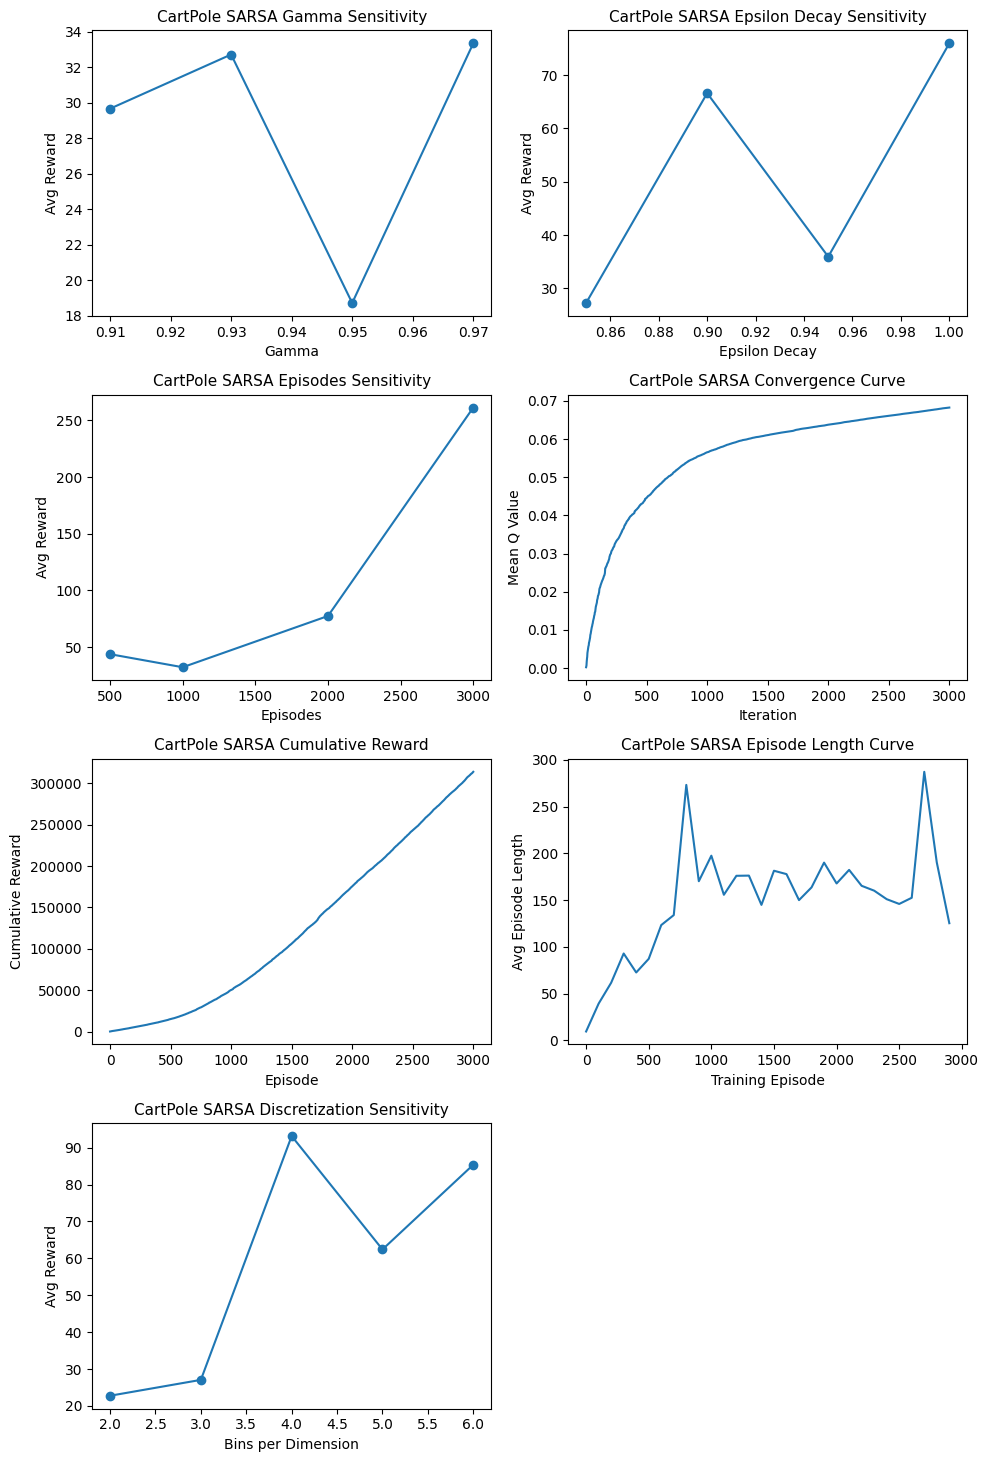

CartPole SARSA | Best Params: Gamma=0.91, Eps Decay=0.9, Episodes=3000


In [16]:
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)

# -------------------------------
# 1. Create and wrap the CartPole environment
# -------------------------------
base_env = gym.make("CartPole-v1", render_mode=None)
base_env.reset(seed=seed_value)
cartpole = CartpoleWrapper(base_env)

# -------------------------------
# 2. Helper Functions
# -------------------------------
def evaluate_policy(env, pi, n_iters=100):
    rewards = []
    for _ in range(n_iters):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = pi[obs]
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return np.mean(rewards)

def run_sarsa_and_test(env, gamma, epsilon_decay, n_episodes):
    Q, V, pi, Q_track, pi_track, rewards = RL(env).sarsa(
        nS=len(env.P),
        nA=env.env.action_space.n,
        gamma=gamma,
        init_alpha=0.5,
        min_alpha=0.01,
        alpha_decay_ratio=0.5,
        init_epsilon=1.0,
        min_epsilon=0.1,
        epsilon_decay_ratio=epsilon_decay,
        n_episodes=n_episodes
    )
    avg_reward = evaluate_policy(env, pi)
    return avg_reward, rewards, Q_track, pi, pi_track

def compute_q_convergence(Q_track):
    return list(np.trim_zeros(np.mean(Q_track, axis=(1, 2)), 'b'))

def compute_episode_length_curve(pi_track, env, sample_interval=100, num_samples=10):
    lengths = []
    for i in range(0, len(pi_track), sample_interval):
        avg_length = []
        for _ in range(num_samples):
            obs, _ = env.reset()
            done = False
            pi = pi_track[i]
            step_count = 0
            while not done:
                action = pi[obs]
                obs, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                step_count += 1
            avg_length.append(step_count)
        lengths.append(np.mean(avg_length))
    return lengths

# -------------------------------
# 3. Hyperparameter Grid
# -------------------------------
gamma_candidates = [0.91, 0.93, 0.95, 0.97]
epsilon_decay_candidates = [0.85, 0.9, 0.95, 1.0]
episodes_candidates = [500, 1000, 2000, 3000]

# -------------------------------
# 4. Grid Search
# -------------------------------
sarsa_results, best_avg_reward, best_params = GridSearch.sarsa_grid_search(
    cartpole,
    gamma=gamma_candidates,
    epsilon_decay=epsilon_decay_candidates,
    iters=episodes_candidates,
    verbose=True
)

print("\nBest SARSA Avg Reward:", best_avg_reward)
print("Best Params:", best_params)

# -------------------------------
# 5. Final SARSA run
# -------------------------------
best_gamma, best_decay, best_eps = best_params
final_avg_reward, rewards_hist, Q_track_final, final_pi, pi_track = run_sarsa_and_test(
    cartpole, best_gamma, best_decay, best_eps)

cartpole_sarsa_reward_record = rewards_hist

# -------------------------------
# 6. Metrics
# -------------------------------
convergence_curve = compute_q_convergence(Q_track_final)
cumulative_rewards = np.cumsum(rewards_hist)
episode_lengths = compute_episode_length_curve(pi_track, cartpole)
iterations_sampled = list(range(0, len(pi_track), 100))

# -------------------------------
# 7. Sensitivity Plots
# -------------------------------
baseline_gamma = 0.91
baseline_decay = 0.85
baseline_eps = 500

gamma_sens = [run_sarsa_and_test(cartpole, g, baseline_decay, baseline_eps)[0] for g in gamma_candidates]
decay_sens = [run_sarsa_and_test(cartpole, baseline_gamma, d, baseline_eps)[0] for d in epsilon_decay_candidates]
eps_sens = [run_sarsa_and_test(cartpole, baseline_gamma, baseline_decay, e)[0] for e in episodes_candidates]

# -------------------------------
# 8. Discretization Sensitivity
# -------------------------------
bin_settings = [2, 3, 4, 5, 6]
avg_rewards_bins = []
for b in bin_settings:
    env = gym.make("CartPole-v1")
    wrapped = CartpoleWrapper(env, position_bins=b, velocity_bins=b, angular_velocity_bins=b)
    _, _, _, pi, _ = run_sarsa_and_test(wrapped, gamma=best_gamma, epsilon_decay=best_decay, n_episodes=best_eps)
    avg_rewards_bins.append(evaluate_policy(wrapped, pi))

# -------------------------------
# 9. Plotting
# -------------------------------
fig, axs = plt.subplots(4, 2, figsize=(10, 16))
fig.delaxes(axs[3, 1])

axs[0, 0].plot(gamma_candidates, gamma_sens, marker='o')
axs[0, 0].set_title("CartPole SARSA Gamma Sensitivity", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Avg Reward")

axs[0, 1].plot(epsilon_decay_candidates, decay_sens, marker='o')
axs[0, 1].set_title("CartPole SARSA Epsilon Decay Sensitivity", fontsize=11)
axs[0, 1].set_xlabel("Epsilon Decay")
axs[0, 1].set_ylabel("Avg Reward")

axs[1, 0].plot(episodes_candidates, eps_sens, marker='o')
axs[1, 0].set_title("CartPole SARSA Episodes Sensitivity", fontsize=11)
axs[1, 0].set_xlabel("Episodes")
axs[1, 0].set_ylabel("Avg Reward")

axs[1, 1].plot(convergence_curve)
axs[1, 1].set_title("CartPole SARSA Convergence Curve", fontsize=11)
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Mean Q Value")

axs[2, 0].plot(cumulative_rewards)
axs[2, 0].set_title("CartPole SARSA Cumulative Reward", fontsize=11)
axs[2, 0].set_xlabel("Episode")
axs[2, 0].set_ylabel("Cumulative Reward")

axs[2, 1].plot(iterations_sampled, episode_lengths)
axs[2, 1].set_title("CartPole SARSA Episode Length Curve", fontsize=11)
axs[2, 1].set_xlabel("Training Episode")
axs[2, 1].set_ylabel("Avg Episode Length")

axs[3, 0].plot(bin_settings, avg_rewards_bins, marker='o')
axs[3, 0].set_title("CartPole SARSA Discretization Sensitivity", fontsize=11)
axs[3, 0].set_xlabel("Bins per Dimension")
axs[3, 0].set_ylabel("Avg Reward")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"CartPole SARSA | Best Params: Gamma={best_gamma}, Eps Decay={best_decay}, Episodes={best_eps}")



## 2.4 Cartpole Qlearning

This section trains a Q-Learning agent on a discretized version of the CartPole-v1 environment.

**Code structure summary:**

1. **Environment Setup**  
   The continuous CartPole environment is wrapped into a discrete MDP using a custom `CartpoleWrapper`.

2. **Helper Functions**  
   - `run_qlearning_and_test`: Executes Q-learning training with specified hyperparameters and returns policy and training metrics.  
   - `evaluate_policy`: Evaluates a learned policy over 100 episodes.  
   - `compute_q_convergence`: Computes the mean Q value at each episode for convergence visualization.  
   - `compute_episode_length_curve`: Computes average episode length at sampling intervals.

3. **Grid Search**  
   Performs exhaustive search over:  
   - `gamma`: [0.91, 0.93, 0.95, 0.97]  
   - `epsilon_decay`: [0.85, 0.9, 0.95, 1.0]  
   - `episodes`: [500, 1000, 2000, 3000]  
   Best parameters are selected based on test-time average reward.

4. **Final Training**  
   Uses the best parameters from grid search to re-train the agent and logs reward history, policy, Q-values, etc.

5. **Visualization**  
   - Sensitivity curves for `gamma`, `epsilon_decay`, and `episodes`  
   - Convergence curve (mean Q value per episode)  
   - Cumulative reward curve  
   - Episode length over training  
   - Discretization sensitivity (reward vs. number of bins per dimension)

running q_learning with gamma: 0.91 epsilon decay: 0.85  iterations: 500


  0%|          | 0/500 [00:00<?, ?it/s]

Avg. episode reward:  47.92
###################
running q_learning with gamma: 0.91 epsilon decay: 0.85  iterations: 1000


  0%|          | 0/1000 [00:00<?, ?it/s]

Avg. episode reward:  125.1
###################
running q_learning with gamma: 0.91 epsilon decay: 0.85  iterations: 2000


...

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

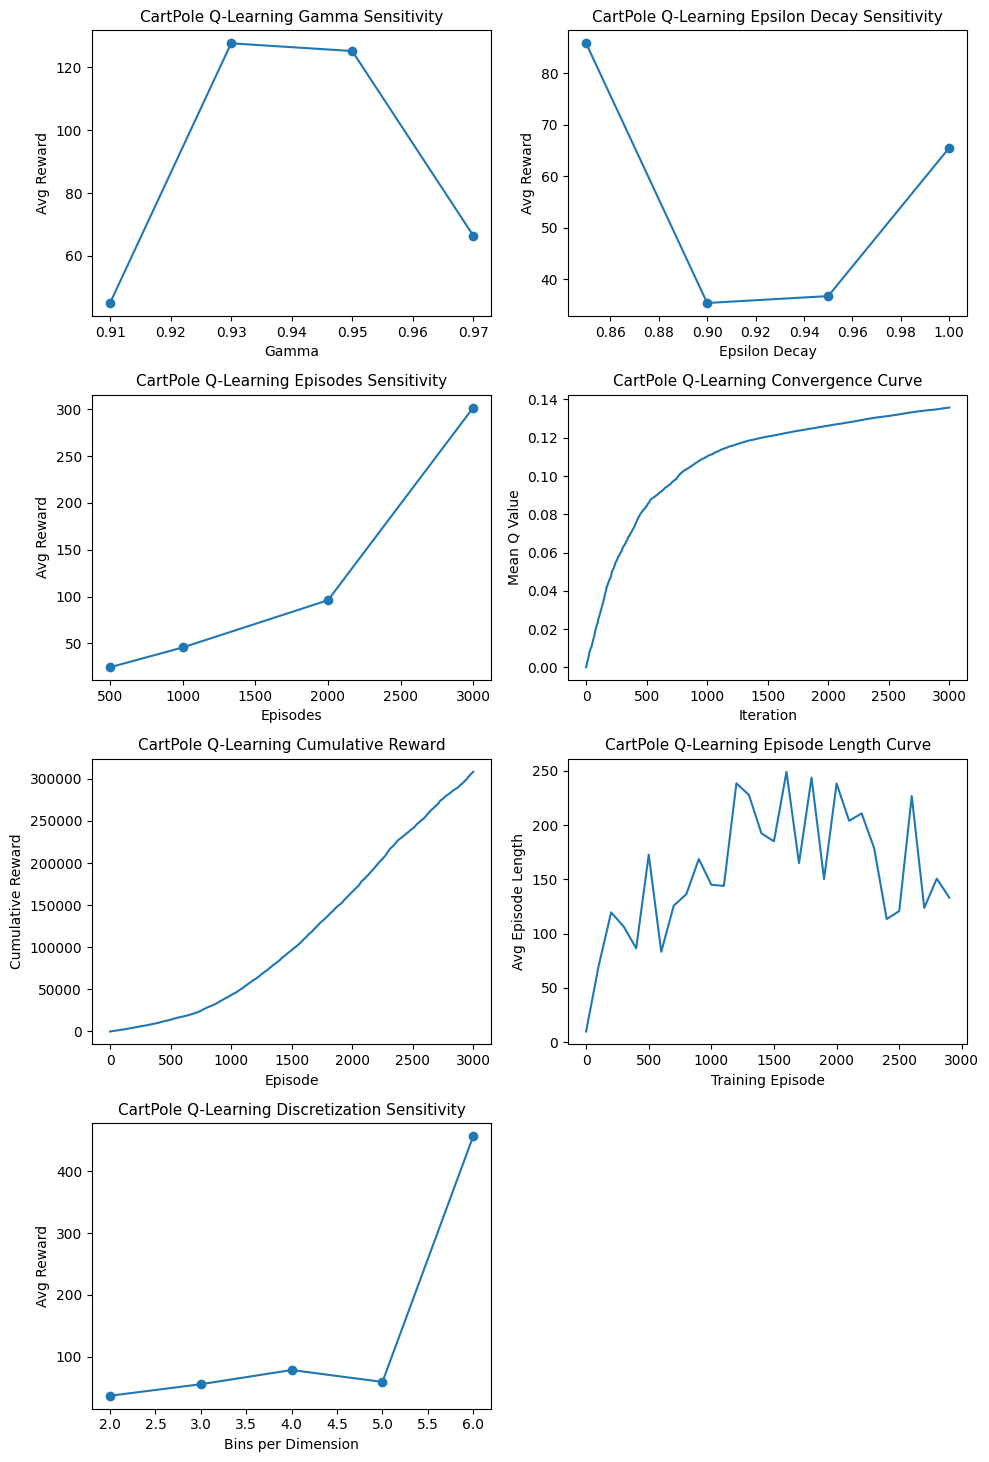

CartPole Q-Learning | Best Params: Gamma=0.97, Eps Decay=1.0, Episodes=3000


In [17]:
# CartPole Q-Learning Analysis
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)

# -------------------------------
# 1. Create and wrap the CartPole environment
# -------------------------------
base_env = gym.make("CartPole-v1", render_mode=None)
base_env.reset(seed=seed_value)
cartpole = CartpoleWrapper(base_env)

# -------------------------------
# 2. Helper Functions
# -------------------------------
def evaluate_policy(env, pi, n_iters=100):
    rewards = []
    for _ in range(n_iters):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = pi[obs]
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return np.mean(rewards)

def run_qlearning_and_test(env, gamma, epsilon_decay, n_episodes):
    Q, V, pi, Q_track, pi_track, rewards = RL(env).q_learning(
        nS=len(env.P),
        nA=env.env.action_space.n,
        gamma=gamma,
        init_alpha=0.5,
        min_alpha=0.01,
        alpha_decay_ratio=0.5,
        init_epsilon=1.0,
        min_epsilon=0.1,
        epsilon_decay_ratio=epsilon_decay,
        n_episodes=n_episodes
    )
    avg_reward = evaluate_policy(env, pi)
    return avg_reward, rewards, Q_track, pi, pi_track

def compute_q_convergence(Q_track):
    return list(np.trim_zeros(np.mean(Q_track, axis=(1, 2)), 'b'))

def compute_episode_length_curve(pi_track, env, sample_interval=100, num_samples=10):
    lengths = []
    for i in range(0, len(pi_track), sample_interval):
        avg_length = []
        for _ in range(num_samples):
            obs, _ = env.reset()
            done = False
            pi = pi_track[i]
            step_count = 0
            while not done:
                action = pi[obs]
                obs, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                step_count += 1
            avg_length.append(step_count)
        lengths.append(np.mean(avg_length))
    return lengths

# -------------------------------
# 3. Hyperparameter Grid
# -------------------------------
gamma_candidates = [0.91, 0.93, 0.95, 0.97]
epsilon_decay_candidates = [0.85, 0.9, 0.95, 1.0]
episodes_candidates = [500, 1000, 2000, 3000]

# -------------------------------
# 4. Grid Search
# -------------------------------
q_results, best_avg_reward, best_params = GridSearch.q_learning_grid_search(
    cartpole,
    gamma=gamma_candidates,
    epsilon_decay=epsilon_decay_candidates,
    iters=episodes_candidates,
    verbose=True
)

print("\nBest Q-Learning Avg Reward:", best_avg_reward)
print("Best Params:", best_params)

# -------------------------------
# 5. Final Q-learning run
# -------------------------------
best_gamma, best_decay, best_eps = best_params
final_avg_reward, rewards_hist, Q_track_final, final_pi, pi_track = run_qlearning_and_test(
    cartpole, best_gamma, best_decay, best_eps)

cartpole_qlearning_reward_record = rewards_hist

# -------------------------------
# 6. Metrics
# -------------------------------
convergence_curve = compute_q_convergence(Q_track_final)
cumulative_rewards = np.cumsum(rewards_hist)
episode_lengths = compute_episode_length_curve(pi_track, cartpole)
iterations_sampled = list(range(0, len(pi_track), 100))

# -------------------------------
# 7. Sensitivity Plots
# -------------------------------
baseline_gamma = 0.91
baseline_decay = 0.85
baseline_eps = 500

gamma_sens = [run_qlearning_and_test(cartpole, g, baseline_decay, baseline_eps)[0] for g in gamma_candidates]
decay_sens = [run_qlearning_and_test(cartpole, baseline_gamma, d, baseline_eps)[0] for d in epsilon_decay_candidates]
eps_sens = [run_qlearning_and_test(cartpole, baseline_gamma, baseline_decay, e)[0] for e in episodes_candidates]

# -------------------------------
# 8. Discretization Sensitivity
# -------------------------------
bin_settings = [2, 3, 4, 5, 6]
avg_rewards_bins = []
for b in bin_settings:
    env = gym.make("CartPole-v1")
    wrapped = CartpoleWrapper(env, position_bins=b, velocity_bins=b, angular_velocity_bins=b)
    _, _, _, pi, _ = run_qlearning_and_test(wrapped, gamma=best_gamma, epsilon_decay=best_decay, n_episodes=best_eps)
    avg_rewards_bins.append(evaluate_policy(wrapped, pi))

# -------------------------------
# 9. Plotting
# -------------------------------
fig, axs = plt.subplots(4, 2, figsize=(10, 16))
fig.delaxes(axs[3, 1])

axs[0, 0].plot(gamma_candidates, gamma_sens, marker='o')
axs[0, 0].set_title("CartPole Q-Learning Gamma Sensitivity", fontsize=11)
axs[0, 0].set_xlabel("Gamma")
axs[0, 0].set_ylabel("Avg Reward")

axs[0, 1].plot(epsilon_decay_candidates, decay_sens, marker='o')
axs[0, 1].set_title("CartPole Q-Learning Epsilon Decay Sensitivity", fontsize=11)
axs[0, 1].set_xlabel("Epsilon Decay")
axs[0, 1].set_ylabel("Avg Reward")

axs[1, 0].plot(episodes_candidates, eps_sens, marker='o')
axs[1, 0].set_title("CartPole Q-Learning Episodes Sensitivity", fontsize=11)
axs[1, 0].set_xlabel("Episodes")
axs[1, 0].set_ylabel("Avg Reward")

axs[1, 1].plot(convergence_curve)
axs[1, 1].set_title("CartPole Q-Learning Convergence Curve", fontsize=11)
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Mean Q Value")

axs[2, 0].plot(cumulative_rewards)
axs[2, 0].set_title("CartPole Q-Learning Cumulative Reward", fontsize=11)
axs[2, 0].set_xlabel("Episode")
axs[2, 0].set_ylabel("Cumulative Reward")

axs[2, 1].plot(iterations_sampled, episode_lengths)
axs[2, 1].set_title("CartPole Q-Learning Episode Length Curve", fontsize=11)
axs[2, 1].set_xlabel("Training Episode")
axs[2, 1].set_ylabel("Avg Episode Length")

axs[3, 0].plot(bin_settings, avg_rewards_bins, marker='o')
axs[3, 0].set_title("CartPole Q-Learning Discretization Sensitivity", fontsize=11)
axs[3, 0].set_xlabel("Bins per Dimension")
axs[3, 0].set_ylabel("Avg Reward")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"CartPole Q-Learning | Best Params: Gamma={best_gamma}, Eps Decay={best_decay}, Episodes={best_eps}")
